In [7]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [8]:
train_path = "../dataset/Brain tumor/Training"
test_path = "../dataset/Brain tumor/Testing"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [11]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(
        0.5
    ),

    Dense(
        4,
        activation="softmax"
    )

])

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

In [14]:
history = model.fit(

    train_generator,

    validation_data=test_generator,

    epochs=10

)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.6889 - loss: 0.7704 - val_accuracy: 0.7400 - val_loss: 0.8435
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.8457 - loss: 0.4152 - val_accuracy: 0.7731 - val_loss: 0.6955
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.8864 - loss: 0.3032 - val_accuracy: 0.8169 - val_loss: 0.6902
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9179 - loss: 0.2266 - val_accuracy: 0.8306 - val_loss: 1.0318
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.9400 - loss: 0.1707 - val_accuracy: 0.8300 - val_loss: 1.1317
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9513 - loss: 0.1363 - val_accuracy: 0.8550 - val_loss: 1.0589
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.9538 - loss: 0.1232 - val_accuracy: 0.8669 - val_loss: 0.7976
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.9695 - loss: 0.0864 - val_accu

In [16]:
model.save("../models/brain_tumor_cnn.keras")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [17]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 312ms/step - accuracy: 0.8906 - loss: 1.1720
Test Loss: 1.1720
Test Accuracy: 0.8906


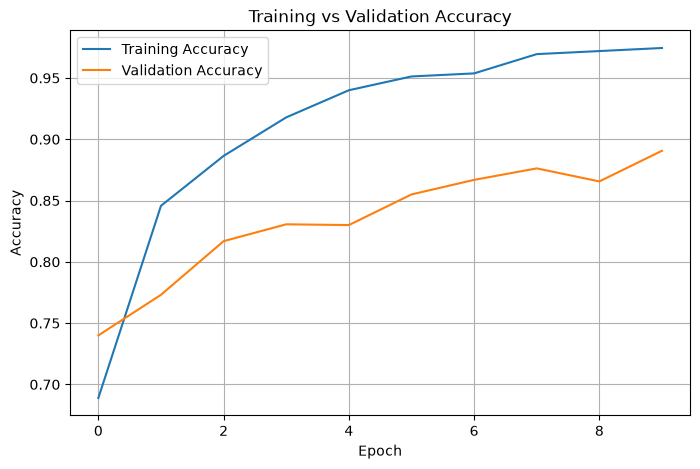

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

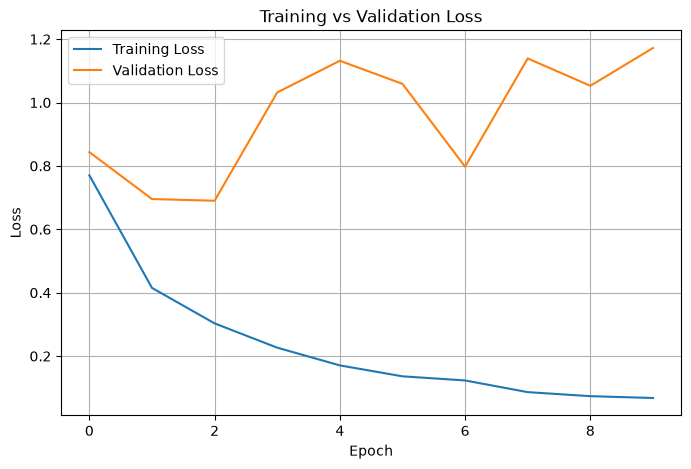

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv("../models/training_history.csv", index=False)

print("Training history saved successfully!")

Training history saved successfully!
